# 04 — Arc Pro B60 single-node characterization

Standalone. This notebook does **not** import or run 01/02/03 and has **no NPU path** — these
desktops have no NPU, so notebook 03's NPU-vs-iGPU comparison doesn't apply here. It
characterizes one discrete **Arc Pro B60** (24 GB, Battlemage, `xe` driver) in an ordinary
desktop, producing the per-node numbers the *two-B60-vs-RTX-6000-Ada* cost comparison is built
from.

It measures three things on a single node:

1. **Validation** — a backend is up on `:8000` and the B60's memory is readable via `xe` fdinfo.
2. **Single-stream baseline** — uncontended TTFT, decode tok/s, and peak footprint.
3. **Concurrency sweep** — aggregate throughput and tail latency as in-flight requests climb.
   The point where aggregate tok/s stops rising is this B60's serving capacity for the model.

**Operator prerequisite** — bring up exactly one OpenAI-compatible backend on `127.0.0.1:8000`
first (vLLM-XPU recommended for the cost story, or OpenVINO Model Server). Start with a small public
VLM (e.g. `Qwen2.5-VL-3B-Instruct`) to prove the path, then swap in your target model. See the README
for the `docker run --device /dev/dri` commands; confirm `curl -s http://127.0.0.1:8000/v1/models`
answers before running this.

In [1]:
import sys, pathlib, json, time, os, grp
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from bench import client, memprobe, sweep, plotting
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = pathlib.Path.cwd().parent
print('bench package imports OK')

bench package imports OK


## Edit per run

The only cell you touch. Keep `MAX_TOKENS` and `CONCURRENCY_LEVELS` fixed across nodes/models so
the runs stay comparable — those are what make `b60-desk-1` and `b60-desk-2` line up in the
Phase-2 chart.

In [2]:
# ---- EDIT PER RUN ----
NODE         = 'b60-desk-1'              # label for this desktop / B60 (used in the output filename)
# MODEL        = 'gemma-4-31B-it-int4-AutoRound'  # MUST match the name the backend serves
MODEL        = 'Qwen3.6-27B-AWQ-INT4'  # MUST match the name the backend serves
QUANTIZATION = 'INT4'                    # INT4 / INT8 / FP16 — for the record and the write-up

BASE_URL = 'http://127.0.0.1:8000/v1'
PORT     = 8000

MAX_TOKENS         = 256                 # fixed generation length per request (keeps levels comparable)
CONCURRENCY_LEVELS = [1, 2, 4, 8, 12]    # in-flight-request counts to sweep
WINDOW_S           = 60.0                # measured seconds per level (longer = more completions = steadier tok/s)
COOLDOWN_S         = 10.0                # pause between levels so the desktop's thermals settle
VRAM_TOTAL_MB      = 24576               # 24 GB B60 — for the footprint-headroom readout
# ----------------------

OUT_DIR   = REPO_ROOT / 'data' / 'b60'
PROMPTS   = json.loads((REPO_ROOT / 'data' / 'prompts.json').read_text())['text_only']
TIMESTAMP = time.strftime('%Y%m%d-%H%M%S')
MODEL_SLUG = ''.join(ch if (ch.isalnum() or ch in '-._') else '-' for ch in MODEL)
OUT_PATH  = OUT_DIR / f'{NODE}_{MODEL_SLUG}_{TIMESTAMP}.json'

print(f'node    : {NODE}')
print(f'model   : {MODEL}  ({QUANTIZATION})')
print(f'sweep   : concurrency {CONCURRENCY_LEVELS}, {WINDOW_S:.0f}s/level, cooldown {COOLDOWN_S:.0f}s')
print(f'prompts : {[p["id"] for p in PROMPTS]}  (text-only, from data/prompts.json)')
print(f'output  : {OUT_PATH}')

node    : b60-desk-1
model   : Qwen3.6-27B-AWQ-INT4  (INT4)
sweep   : concurrency [1, 2, 4, 8, 12], 60s/level, cooldown 10s
prompts : ['t-short', 't-medium', 't-long']  (text-only, from data/prompts.json)
output  : /home/jake/git/vlm-notebooks/data/b60/b60-desk-1_Qwen3.6-27B-AWQ-INT4_20260612-204046.json


## Section 1 — Validation

Must pass before anything else runs: the backend answers `/v1/models`, `MODEL` is one of the
served names, and — after one warmup so the server issues GPU work — the B60's resident memory is
readable from `/proc/<pid>/fdinfo` (the `drm-resident-*` keys the `xe` driver exposes; no root
needed). Also checks the card is passed to the host (`/dev/dri/renderD128`, render group) and
records the PCIe link width for the write-up.

In [3]:
import openai

# 1a. card passed to this host: /dev/dri present, user in the render group.
render = pathlib.Path('/dev/dri/renderD128')
print('renderD128 present :', render.exists())
try:
    in_render = grp.getgrnam('render').gr_gid in os.getgroups()
    print('user in render grp :', in_render)
except KeyError:
    print('render group       : not found on this distro (check your GPU group)')

# 1b. PCIe link of the B60 (Gen5 x8 may down-train in a desktop slot) — from /sys, no root.
def _pcie_link():
    for card in sorted(pathlib.Path('/sys/class/drm').glob('card*')):
        dev = card / 'device'
        sp, wd = dev / 'current_link_speed', dev / 'current_link_width'
        if sp.exists() and wd.exists():
            try:
                return f'{sp.read_text().strip()} x{wd.read_text().strip()}'
            except Exception:
                pass
    return None
PCIE_LINK = _pcie_link()
print('PCIe link (1st card):', PCIE_LINK or 'unavailable — try: sudo lspci -vv | grep -A2 LnkSta')

# 1c. backend answers /v1/models and serves MODEL.
served = [m.id for m in openai.OpenAI(base_url=BASE_URL, api_key='EMPTY').models.list().data]
print('served models      :', served)
assert served, f'no models served on :{PORT} — bring up a backend first (see README)'
if MODEL not in served:
    print(f'WARNING: MODEL={MODEL!r} not served; falling back to {served[0]!r} for this run')
    MODEL = served[0]

# 1d. find server PID, warm once so it touches the GPU, then read B60 memory via fdinfo.
pid = memprobe.find_server_pid(PORT)
print('server pid         :', pid)
assert pid, f'no process found listening on :{PORT}'
client.warmup(base_url=BASE_URL, model=MODEL)
igpu = memprobe._read_igpu_mem_mb(pid)
assert igpu is not None, (
    'B60 memory not readable via fdinfo — is the server holding a /dev/dri fd? '
    'Needs the xe driver bound to the card and --device /dev/dri passed to the container.')
print(f'B60 resident memory: {igpu:.0f} MB  ({igpu/VRAM_TOTAL_MB*100:.1f}% of {VRAM_TOTAL_MB} MB) '
      '— readable via xe fdinfo  ✓')

renderD128 present : True
user in render grp : True
PCIe link (1st card): Unknown x0
served models      : ['cyankiwi/Qwen3.6-27B-AWQ-INT4']
server pid         : 33999
B60 resident memory: 23022 MB  (93.7% of 24576 MB) — readable via xe fdinfo  ✓


## Section 2 — Single-stream baseline

Five sequential streaming calls with nothing else in flight: uncontended TTFT, decode tok/s, and
the model's peak footprint in the 24 GB. The footprint line tells you how much room is left for
KV cache at your target context — swap `MODEL` to your target model (e.g. a 27B INT4/AWQ) and
re-run to confirm it fits before building the two-node test. The Ada will beat the B60 on
single-request latency; that's expected and fine — the B60 story is throughput-per-dollar.

In [4]:
with memprobe.MemProbe(pid=pid, interval_s=0.5) as probe:
    baseline = sweep.single_stream(
        base_url=BASE_URL, model=MODEL, prompts=PROMPTS, max_tokens=MAX_TOKENS, repeats=5,
    )
pk = probe.peak()
peak_rss  = pk.rss_mb if pk else None
peak_igpu = max((s.igpu_mb for s in probe.samples if s.igpu_mb is not None), default=None)
baseline['peak_rss_mb']  = round(peak_rss, 1) if peak_rss else None
baseline['peak_igpu_mb'] = round(peak_igpu, 1) if peak_igpu else None

print('single-stream baseline (median of 5 sequential calls):')
if baseline['streaming']:
    print(f"  TTFT          : {baseline['ttft_s']} s")
    print(f"  decode tok/s  : {baseline['decode_tps']}")
else:
    print('  TTFT/decode   : n/a — backend did not stream (see caveats); latency still measured')
print(f"  total latency : {baseline['latency_s']} s  ({baseline['completion_tokens']} tok)")
print()
if peak_igpu is not None:
    headroom = VRAM_TOTAL_MB - peak_igpu
    print(f"  B60 footprint : {peak_igpu:.0f} MB resident "
          f"({peak_igpu/VRAM_TOTAL_MB*100:.1f}% of {VRAM_TOTAL_MB} MB) — "
          f"{headroom:.0f} MB / {headroom/1024:.1f} GB headroom for KV cache")
print(f"  server RSS    : {peak_rss:.0f} MB" if peak_rss else "  server RSS    : unreadable")

single-stream baseline (median of 5 sequential calls):
  TTFT          : 0.147 s
  decode tok/s  : 18.6
  total latency : 13.927 s  (256 tok)

  B60 footprint : 23023 MB resident (93.7% of 24576 MB) — 1553 MB / 1.5 GB headroom for KV cache
  server RSS    : 6759 MB


## Section 3 — Concurrency sweep

Drives `CONCURRENCY_LEVELS` in-flight requests back-to-back for `WINDOW_S` each (cooling down
between levels), sampling the server's footprint throughout. One line per level: aggregate decode
tok/s, p95 TTFT, completed requests, errors. The **knee** is the cheapest concurrency that reaches
essentially peak throughput (within 10% of the best level) — that's this B60's serving capacity.
Picking it relative to the peak (rather than stopping at the first step that doesn't gain 10%)
keeps a flat or noisy early step from pinning the knee at 1. If throughput later **drops** below
the peak, the run is flagged over-subscribed past that point. The full run is saved to
`data/b60/<NODE>_<MODEL>_<timestamp>.json`, the input to the Phase-2 two-node cost chart.

In [5]:
results = []
for i, c in enumerate(CONCURRENCY_LEVELS):
    with memprobe.MemProbe(pid=pid, interval_s=0.5) as probe:
        lr = sweep.sweep_level(
            concurrency=c, window_s=WINDOW_S,
            base_url=BASE_URL, model=MODEL, prompts=PROMPTS, max_tokens=MAX_TOKENS,
        )
    pk = probe.peak()
    lr.peak_rss_mb  = pk.rss_mb if pk else None
    lr.peak_igpu_mb = max((s.igpu_mb for s in probe.samples if s.igpu_mb is not None), default=None)
    s = lr.summary()
    results.append(s)
    ttft = f"TTFT p95 {s['ttft_p95']}s" if s['streaming'] else "TTFT n/a"
    print(f"c={c:>2}  agg {s['agg_tokens_per_s']:>7.1f} tok/s   {ttft:<16}  "
          f"done {s['completed']:>4}  err {s['errors']}")
    if COOLDOWN_S and i < len(CONCURRENCY_LEVELS) - 1:
        time.sleep(COOLDOWN_S)

report = sweep.capacity_report(results)
cap, peak = report['knee'], report['peak']
print(f"\nserving capacity (knee): ~{cap['concurrency']} in-flight -> {cap['agg_tokens_per_s']} tok/s")
print(f"peak throughput        : {peak['agg_tokens_per_s']} tok/s at {peak['concurrency']} in-flight")
if report['saturated']:
    print(f"NOTE: throughput falls past {peak['concurrency']} in-flight — the B60 is over-subscribed "
          "beyond its knee; don't push concurrency higher for this model.")

out = sweep.save_sweep(
    path=OUT_PATH, node=NODE, model=MODEL, quantization=QUANTIZATION,
    vram_total_mb=VRAM_TOTAL_MB, max_tokens=MAX_TOKENS, base_url=BASE_URL,
    baseline=baseline, levels=results, timestamp=TIMESTAMP,
    meta={
        'knee_concurrency': cap['concurrency'],
        'knee_tokens_per_s': cap['agg_tokens_per_s'],
        'peak_concurrency': peak['concurrency'],
        'peak_tokens_per_s': peak['agg_tokens_per_s'],
        'saturated': report['saturated'],
        'pcie_link': PCIE_LINK,
        'prompt_ids': [p['id'] for p in PROMPTS],
    },
)
print('saved', out)

c= 1  agg    16.9 tok/s   TTFT p95 0.147s   done    5  err 0
c= 2  agg    33.8 tok/s   TTFT p95 0.236s   done   10  err 0
c= 4  agg    55.0 tok/s   TTFT p95 0.316s   done   16  err 0
c= 8  agg   112.2 tok/s   TTFT p95 0.436s   done   32  err 0
c=12  agg   109.3 tok/s   TTFT p95 0.438s   done   36  err 0

serving capacity (knee): ~8 in-flight -> 112.2 tok/s
peak throughput        : 112.2 tok/s at 8 in-flight
NOTE: throughput falls past 8 in-flight — the B60 is over-subscribed beyond its knee; don't push concurrency higher for this model.
saved /home/jake/git/vlm-notebooks/data/b60/b60-desk-1_Qwen3.6-27B-AWQ-INT4_20260612-204046.json


## Section 4 — Throughput and TTFT vs concurrency

Left: aggregate decode tok/s vs concurrency — the capacity curve; the knee is marked. Right: TTFT
p50/p95 vs concurrency (a placeholder if the backend didn't stream). The knee number, doubled and
divided by (2 × GPU cost) and (2 × board watts), is the honest cost-effectiveness figure against
the single RTX 6000 Ada.

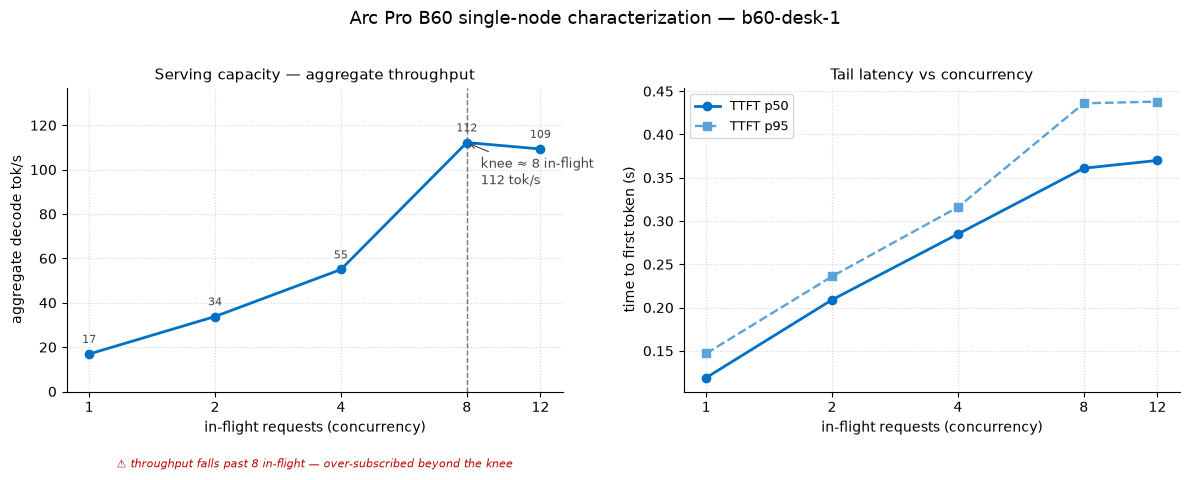

In [6]:
fig, axes = plotting.sweep_curves(
    results, knee_concurrency=cap['concurrency'],
    peak_concurrency=peak['concurrency'], saturated=report['saturated'],
    node_label=NODE,
)
plt.show()

## How to read the results

- **Throughput curve (left).** The knee — where aggregate tok/s flattens — is this B60's serving
  capacity for the model. That number, doubled and divided by (2 × GPU cost) and (2 × board
  watts), is the honest cost-effectiveness figure against the single RTX 6000 Ada.
- **Footprint (section 2).** Confirms the model fits in 24 GB with enough headroom for KV cache at
  your target context. Swap `MODEL` to your target model (e.g. a 27B INT4/AWQ) and re-run to check
  it before building the two-node test.
- **Latency (right).** The Ada wins single-request TTFT/decode — expected and fine. The B60 story
  is throughput-per-dollar and ease of setup, not per-request speed.

### Next (Phase 2)

Once both desktops each pass this notebook, the cost comparison is a two-node data-parallel test:
one model instance per B60 behind a load balancer / Ray Serve, driven under concurrent load, with
**tokens/s/$** and **tokens/s/W** as the headline metrics versus the single Ada. The per-node
JSONs saved under `data/b60/` are the inputs to that combined chart (see notebook 05).

## Caveats (record these in any write-up)

- **PCIe link.** The B60 is Gen5 x8; an ordinary desktop slot may down-train it. Section 1 reads
  `current_link_speed`/`current_link_width` from `/sys` (best-effort, first card). For the
  authoritative read capture `sudo lspci -vv | grep -A2 LnkSta` for the card and note it.
- **Power for tokens/s/W.** If you can read board power (outlet meter, or `xpu-smi` where
  available), log it per level and divide `agg_tokens_per_s` by watts — the metric that most
  favors the B60.
- **No SSE streaming.** If the backend doesn't stream, `client.call` falls back to non-streaming,
  so TTFT/decode read `None` and the latency panel shows a placeholder; aggregate throughput still
  computes.
- **Software maturity.** Arc XPU serving is younger than the CUDA path; the saved JSON records
  `base_url` and you should note the image/driver versions so results reproduce. Frame any gap as
  "already cost-competitive on an immature stack."
- **Thermals.** A desktop under sustained load heats up; `COOLDOWN_S` between levels lets it
  settle so heat soak doesn't masquerade as a capacity drop. Ideally repeat and average.